In [ ]:
from github_helper import from_github
import pandas as pd
from tqdm import tqdm
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from overseas_parties import overseas_parties

In [34]:
edge_df = pd.read_csv(from_github("/edges/party/all_party_edges_by_Period.csv"))

edge_df = edge_df[edge_df['Period']!=65] #We drop Period 65, as it does not seem to be representative. This is already done in the dataframe building, but needs to be propogated up to here.

# edge_df.head()



In [ ]:

overseas_parties

{'Fólkaflokkurin',
 'Inuit Ataqatigiit',
 'Javnaðarflokkurin',
 'Naleraq',
 'Sambandsflokkurin',
 'Siumut',
 'Tjóðveldi',
 'Uden for Folketingsgrupperne'}

In [63]:
# traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"] #Not sure about this
# mask_only_traditional_parties = (edge_df['source'].isin(traditional_parties)) & (edge_df['target'].isin(traditional_parties))
overseas_parties_mask = (edge_df['source'].isin(overseas_parties) | edge_df['target'].isin(overseas_parties)) #Remove overseas parties as they have incredibly few representatives, so their "Agreement" is extremely volatile, which affects the calculations too much.
la_66_mask = (((edge_df['source'] == "Liberal Alliance") | (edge_df['target'] == "Liberal Alliance")) & (edge_df['Period'] == 66)) #Also remove LA in 66, as they just started at the very end of their period.
edge_traditional = edge_df[(~overseas_parties_mask) & (~la_66_mask)]

#Remove self-relations
self_edges = (edge_traditional['source'] == edge_traditional['target'])
edge_traditional = edge_traditional[~self_edges]

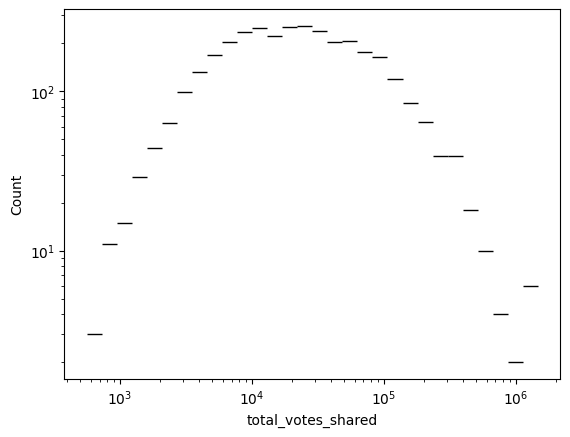

In [64]:
sns.histplot(
    data = edge_traditional
    ,x = "total_votes_shared"
    ,bins = 30
    ,log_scale= (True, True)
)

edge_traditional = edge_traditional[edge_traditional['total_votes_shared']>=100]



In [65]:
periods = [66, 67, 68, 69, 70, 71] # 65
wide = (
    edge_traditional
    .pivot_table(
        index=['source', 'target', 'topic'],  # one row per pair+topic
        columns='Period',                     # one column per period
        values='weight',                      # values to fill
        aggfunc='first'                       # or 'mean' if you can have duplicates
    )
    .reindex(columns=periods)                 # ensure column order 65..71
)

# make Period columns normal columns instead of a MultiIndex
wide = wide.reset_index()
wide

Period,source,target,topic,66,67,68,69,70,71
0,Alternativet,Danmarksdemokraterne,arbejdsmarked_velfærd,NaN,NaN,NaN,NaN,NaN,0.639408
1,Alternativet,Danmarksdemokraterne,bolig,NaN,NaN,NaN,NaN,NaN,0.441583
2,Alternativet,Danmarksdemokraterne,erhverv,NaN,NaN,NaN,NaN,NaN,0.652568
3,Alternativet,Danmarksdemokraterne,finans_budget,NaN,NaN,NaN,NaN,NaN,0.529687
4,Alternativet,Danmarksdemokraterne,forsvar_sikkerhed,NaN,NaN,NaN,NaN,NaN,0.650256
...,...,...,...,...,...,...,...,...,...
985,Socialistisk Folkeparti,Venstre,social_familie,0.346316,0.513698,0.733206,0.547452,0.597048,0.721881
986,Socialistisk Folkeparti,Venstre,sundhed,0.404409,0.496409,0.706033,0.531444,0.636102,0.701161
987,Socialistisk Folkeparti,Venstre,transport_infrastruktur,0.461694,0.573860,0.707123,0.536177,0.515975,0.655168
988,Socialistisk Folkeparti,Venstre,uddannelse,0.390628,0.538501,0.713759,0.518200,0.606464,0.644915


In [66]:
diffs = []
for a, b in combinations(periods, 2):
    # Compute difference but set it to NaN if either side is NaN
    diff = (wide[a] - wide[b]).abs()
    
    # mask invalid diffs where one or both values were missing
    invalid_mask = wide[[a, b]].isna().any(axis=1)
    diff[invalid_mask] = np.nan
    
    diffs.append(diff)

# Combine while ignoring NaN values
wide["biggest_change"] = np.nanmax(np.column_stack(diffs), axis=1)
wide_sorted = wide.sort_values("biggest_change", ascending=False)
wide_sorted

C:\Users\ThorNørgaardEriksen\AppData\Local\Temp\ipykernel_43916\260889374.py:13: RuntimeWarning: All-NaN slice encountered
  wide["biggest_change"] = np.nanmax(np.column_stack(diffs), axis=1)


Period,source,target,topic,66,67,68,69,70,71,biggest_change
441,Dansk Folkeparti,Venstre,immigration,0.904362,0.869726,0.633011,0.686584,0.606890,0.281978,0.622384
666,Enhedslisten,Venstre,immigration,0.200180,0.233423,0.400780,0.338009,0.452077,0.703677,0.503497
963,Socialdemokratiet,Venstre,finans_budget,0.578015,0.515794,0.635412,0.692905,0.653585,0.995905,0.480111
967,Socialdemokratiet,Venstre,klima_miljø,0.535073,0.593235,0.684935,0.820806,0.802141,0.995599,0.460526
971,Socialdemokratiet,Venstre,sundhed,0.579778,0.539194,0.746228,0.848366,0.757642,0.996502,0.457308
...,...,...,...,...,...,...,...,...,...,...
835,Moderaterne,Venstre,social_familie,NaN,NaN,NaN,NaN,NaN,0.961335,NaN
836,Moderaterne,Venstre,sundhed,NaN,NaN,NaN,NaN,NaN,0.973331,NaN
837,Moderaterne,Venstre,transport_infrastruktur,NaN,NaN,NaN,NaN,NaN,0.964208,NaN
838,Moderaterne,Venstre,uddannelse,NaN,NaN,NaN,NaN,NaN,0.969966,NaN


<Axes: xlabel='biggest_change', ylabel='Count'>

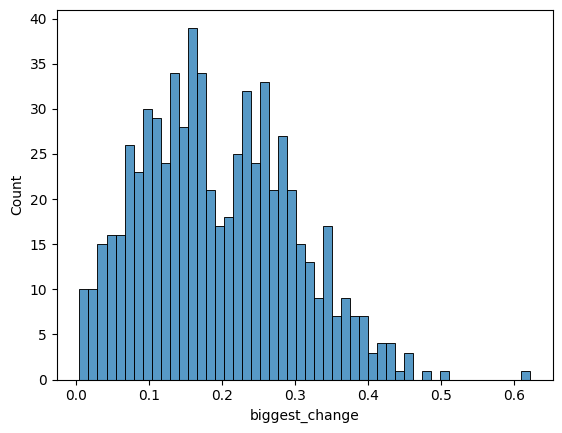

In [67]:
sns.histplot(
    data = wide_sorted
    ,x = "biggest_change"
    ,bins = 50
)

In [50]:
wide_sorted["diff_66_71"] = (wide_sorted[71] - wide_sorted[66]).abs()
wide_sorted

Period,source,target,topic,66,67,68,69,70,71,biggest_change,diff_66_71
1562,Tjóðveldi,Venstre,social_familie,0.000000,NaN,1.0,0.155738,NaN,NaN,1.000000,NaN
1558,Tjóðveldi,Venstre,general,0.137681,0.674620,1.0,0.111111,NaN,NaN,0.888889,NaN
770,Enhedslisten,Inuit Ataqatigiit,finans_budget,NaN,NaN,NaN,0.135615,0.989691,NaN,0.854076,NaN
1471,Socialdemokratiet,Tjóðveldi,general,0.518090,0.680191,1.0,0.151634,NaN,NaN,0.848366,NaN
1475,Socialdemokratiet,Tjóðveldi,social_familie,1.000000,NaN,1.0,0.161111,NaN,NaN,0.838889,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1470,Socialdemokratiet,Tjóðveldi,forsvar_sikkerhed,0.120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1474,Socialdemokratiet,Tjóðveldi,skat,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1554,Tjóðveldi,Venstre,arbejdsmarked_velfærd,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1557,Tjóðveldi,Venstre,forsvar_sikkerhed,0.003311,NaN,NaN,NaN,NaN,NaN,NaN,NaN


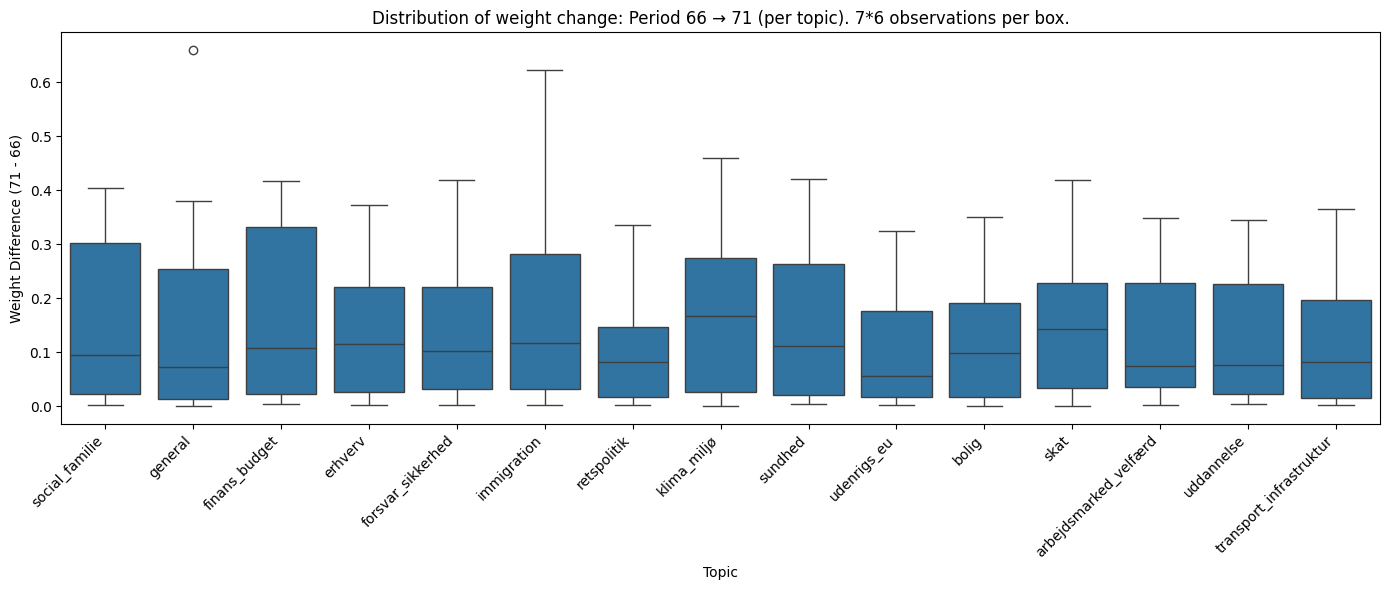

In [51]:

# medians = wide_sorted.groupby("topic")["diff_66_71"].mean().sort_values()
# wide_sorted["topic"] = pd.Categorical(
#     wide_sorted["topic"],
#     categories=medians.index,
#     ordered=True
# )


plt.figure(figsize=(14, 6))

sns.boxplot(
    data=wide_sorted,
    x="topic",
    y="diff_66_71",
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of weight change: Period 66 → 71 (per topic). 7*6 observations per box.")
plt.xlabel("Topic")
plt.ylabel("Weight Difference (71 - 66)")

plt.tight_layout()
plt.show()